# Palmer Penguins — An Exploratory Data Analysis

**Goal of this notebook:** take a real public dataset and *tell a story* with it
— show the distributions, find the relationships, and surface one genuinely
surprising result — in a way that a non-technical reader can follow.

**Dataset:** the [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)
dataset: body measurements for 344 penguins of three species (Adelie, Chinstrap,
Gentoo) recorded at the Palmer Station in Antarctica. It is a modern, friendlier
replacement for the classic Iris dataset.

**The punchline (no spoilers, but here's the shape of it):** one pair of
measurements looks *negatively* related across all penguins — yet that
relationship **flips to positive** once you account for the species. This is a
textbook example of **Simpson's paradox**, and it is the single most important
reason to never trust a correlation without looking at the subgroups.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable styling for every figure in the notebook.
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 110

# A fixed, named colour per species so the same colour means the same penguin
# in every chart below.
SPECIES_ORDER = ["Adelie", "Chinstrap", "Gentoo"]
SPECIES_COLORS = dict(zip(SPECIES_ORDER, sns.color_palette("colorblind", 3)))

pd.set_option("display.precision", 2)


## 2. Load the data

We load from a CSV vendored into the repo (`data/penguins.csv`) so the notebook
is fully reproducible and needs no internet connection.


In [2]:
df = pd.read_csv("data/penguins.csv")
print(f"{df.shape[0]} rows x {df.shape[1]} columns")
df.head()


344 rows x 7 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 3. First look: structure and data quality

Before any analysis, we sanity-check the data: column types, how much is
missing, and whether the categories are what we expect. Skipping this step is
how people end up "discovering" findings that are really just data bugs.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
# How many values are missing per column?
missing = df.isna().sum()
missing[missing > 0]


bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

A handful of rows have missing measurements (and `sex` is missing for 11
penguins). With only a few incomplete rows out of 344, and no evidence the gaps
are systematic, we drop them for the measurement analyses rather than impute —
imputing body measurements we don't have would invent data.


In [5]:
before = len(df)
df_clean = df.dropna().reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} incomplete rows; {len(df_clean)} remain.")

# Confirm the categorical columns hold exactly the categories we expect.
for col in ["species", "island", "sex"]:
    print(f"{col:8s}: {sorted(df_clean[col].unique())}")


Dropped 11 incomplete rows; 333 remain.
species : ['Adelie', 'Chinstrap', 'Gentoo']
island  : ['Biscoe', 'Dream', 'Torgersen']
sex     : ['Female', 'Male']


## 4. Who lives where? Composition of the dataset

A quick orientation: how many of each species, and how the species map onto the
three islands.


C:\Users\Afnan\AppData\Local\Temp\ipykernel_8\3294599481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


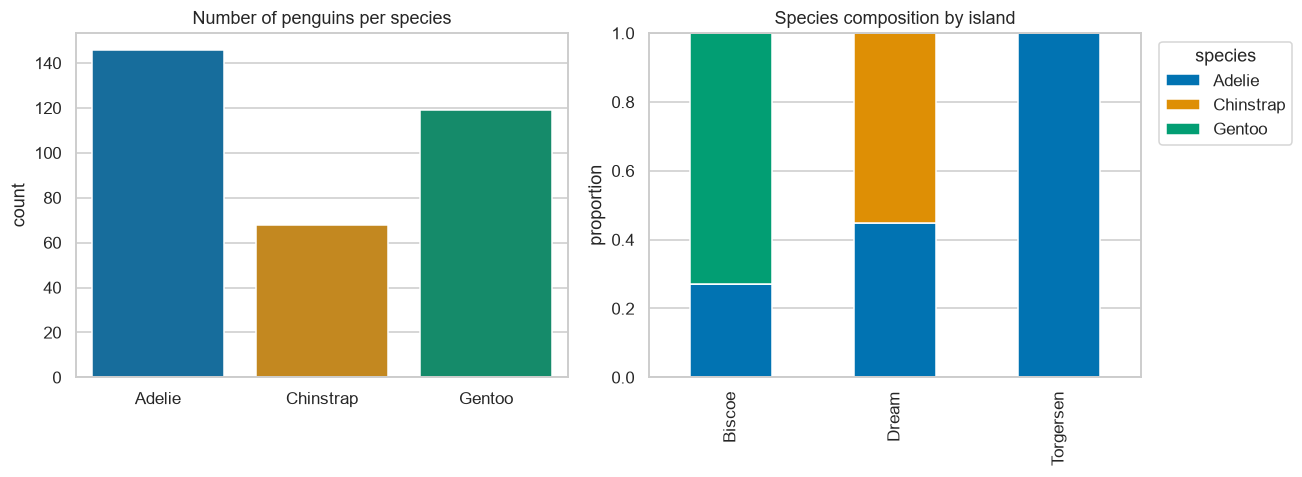

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: count of penguins per species.
sns.countplot(
    data=df_clean, x="species", order=SPECIES_ORDER,
    palette=SPECIES_COLORS, ax=axes[0],
)
axes[0].set_title("Number of penguins per species")
axes[0].set_xlabel(""); axes[0].set_ylabel("count")

# Right: species composition of each island (stacked proportions).
island_species = (
    pd.crosstab(df_clean["island"], df_clean["species"], normalize="index")
    [SPECIES_ORDER]
)
island_species.plot(
    kind="bar", stacked=True, ax=axes[1],
    color=[SPECIES_COLORS[s] for s in SPECIES_ORDER],
)
axes[1].set_title("Species composition by island")
axes[1].set_xlabel(""); axes[1].set_ylabel("proportion")
axes[1].legend(title="species", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("images/01_composition.png", bbox_inches="tight")
plt.show()


**Reading this:** Adelie penguins are the most numerous and the only species
found on all three islands. Gentoo live exclusively on Biscoe, and Chinstrap
exclusively on Dream. Island is therefore a strong clue to species — worth
remembering, because geography will quietly shape later comparisons.


## 5. Distributions of the four body measurements

Each penguin has four numeric measurements: bill length, bill depth, flipper
length and body mass. We plot the distribution of each, split by species, to see
how the species differ.


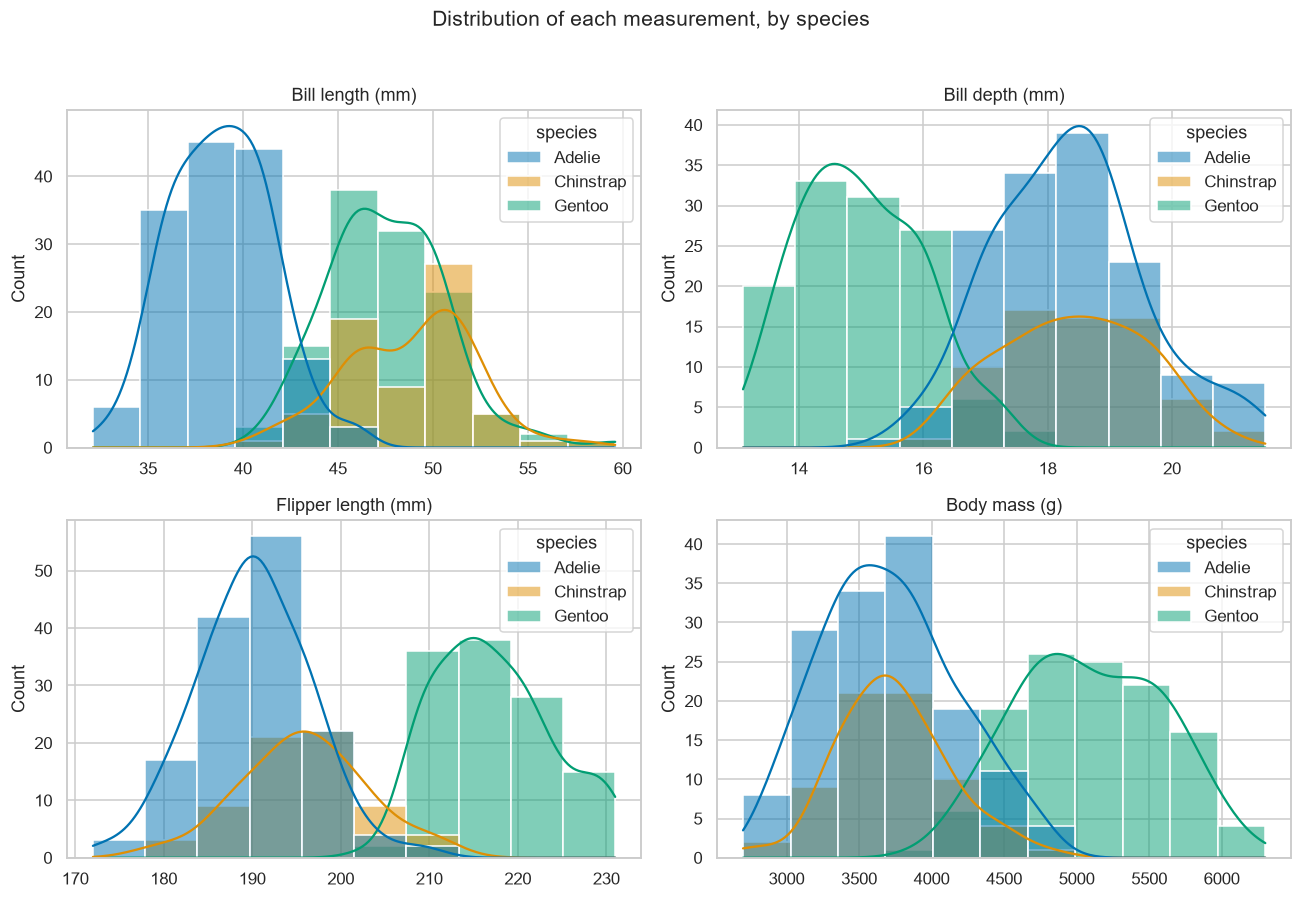

In [7]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
nice_names = {
    "bill_length_mm": "Bill length (mm)",
    "bill_depth_mm": "Bill depth (mm)",
    "flipper_length_mm": "Flipper length (mm)",
    "body_mass_g": "Body mass (g)",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(
        data=df_clean, x=col, hue="species", hue_order=SPECIES_ORDER,
        palette=SPECIES_COLORS, kde=True, alpha=0.5, ax=ax,
    )
    ax.set_title(nice_names[col]); ax.set_xlabel("")
plt.suptitle("Distribution of each measurement, by species", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("images/02_distributions.png", bbox_inches="tight")
plt.show()


**Reading this:** Gentoo penguins stand out — they have notably longer flippers
and greater body mass than the other two species, and the *shallowest* bills.
Adelie penguins have the shortest bills. Chinstrap and Adelie overlap heavily on
body size but separate on bill length. No single measurement perfectly
separates all three species, but together they do a good job.


## 6. Body mass by species and sex

Body mass is the headline "size" variable. Does it differ by sex within each
species?


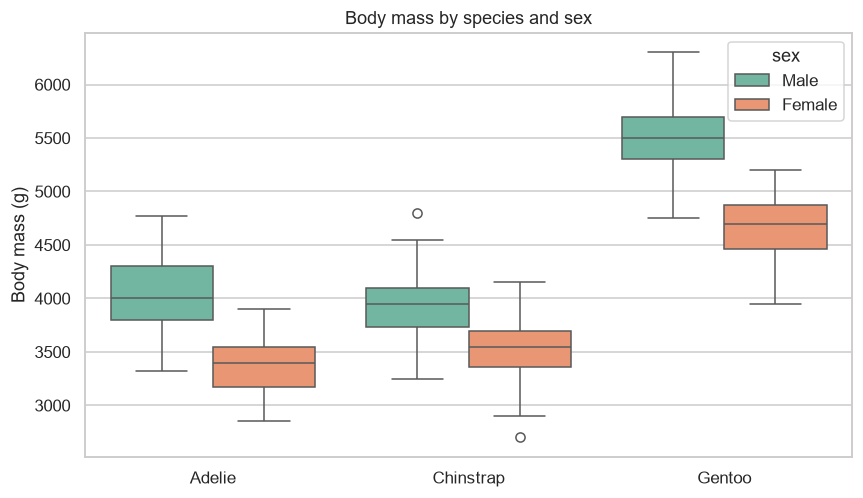

In [8]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean, x="species", y="body_mass_g", hue="sex",
    order=SPECIES_ORDER, palette="Set2",
)
plt.title("Body mass by species and sex")
plt.xlabel(""); plt.ylabel("Body mass (g)")
plt.savefig("images/03_mass_by_sex.png", bbox_inches="tight")
plt.show()


**Reading this:** within every species males are heavier than females, and
Gentoo are heavier than the others regardless of sex. The sex gap is real and
consistent — a reminder that "species" alone doesn't capture all the structure.


## 7. Correlations between measurements

Now the relationships *between* measurements. We start with the overall
correlation matrix across all penguins.


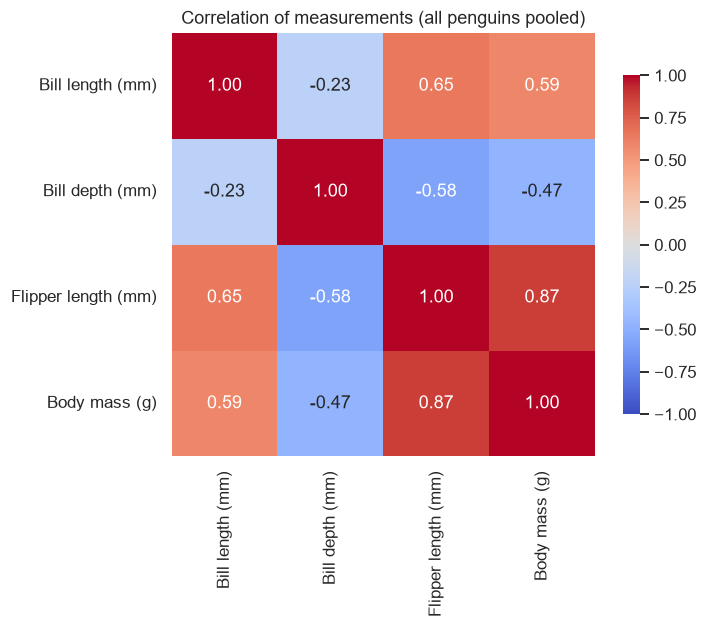

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.23,0.65,0.59
bill_depth_mm,-0.23,1.00,-0.58,-0.47
flipper_length_mm,0.65,-0.58,1.00,0.87
body_mass_g,0.59,-0.47,0.87,1.00


In [9]:
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
    square=True, cbar_kws={"shrink": 0.8},
    xticklabels=[nice_names[c] for c in numeric_cols],
    yticklabels=[nice_names[c] for c in numeric_cols],
)
plt.title("Correlation of measurements (all penguins pooled)")
plt.savefig("images/04_correlation.png", bbox_inches="tight")
plt.show()
corr


**Reading this:** flipper length and body mass are strongly positively
correlated (~0.87) — bigger penguins have bigger flippers, no surprise. But look
at **bill length vs. bill depth**: pooled across all penguins, they are
*negatively* correlated (longer bills tend to be shallower). Hold that thought.


## 8. The surprising finding: Simpson's paradox

The pooled correlation said: **longer bills are shallower** (negative). That
feels odd — why would a longer bill be a thinner one? Let's look at the same two
measurements again, but colour each point by species and fit a trend line *per
species*.


In [10]:
# Pooled correlation (what section 7 reported).
pooled_r = df_clean["bill_length_mm"].corr(df_clean["bill_depth_mm"])

# Correlation computed *within* each species.
within = (
    df_clean.groupby("species")
    .apply(lambda g: g["bill_length_mm"].corr(g["bill_depth_mm"]),
           include_groups=False)
    .reindex(SPECIES_ORDER)
)

print(f"Pooled correlation (all penguins): {pooled_r:+.2f}")
print("Correlation within each species:")
for sp, r in within.items():
    print(f"  {sp:10s}: {r:+.2f}")


Pooled correlation (all penguins): -0.23
Correlation within each species:
  Adelie    : +0.39
  Chinstrap : +0.65
  Gentoo    : +0.65


<Figure size 990x660 with 0 Axes>

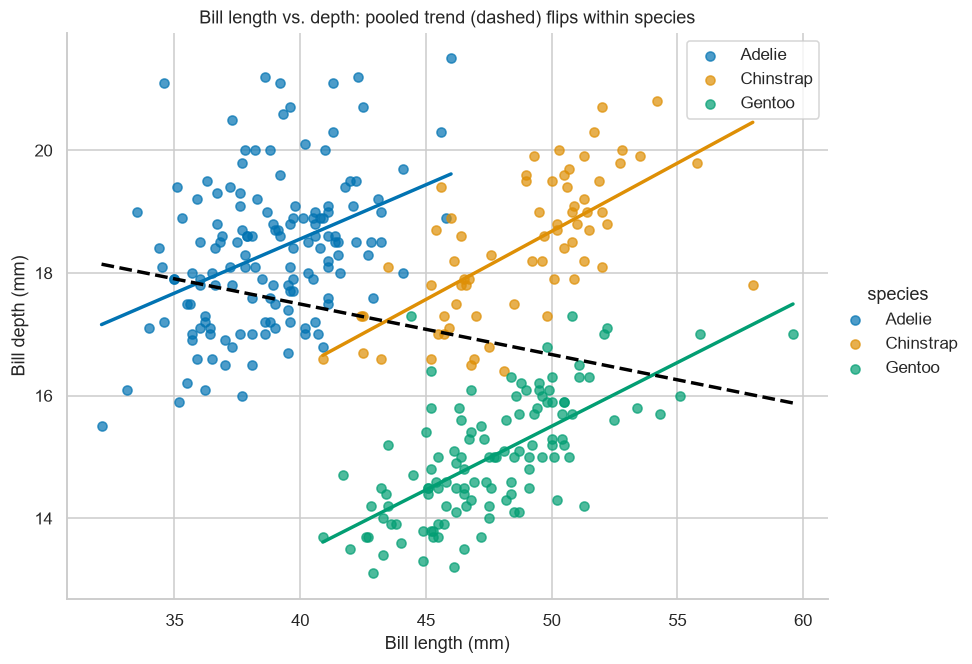

In [11]:
plt.figure(figsize=(9, 6))

# Per-species scatter + regression line: every line slopes UP.
sns.lmplot(
    data=df_clean, x="bill_length_mm", y="bill_depth_mm",
    hue="species", hue_order=SPECIES_ORDER, palette=SPECIES_COLORS,
    height=6, aspect=1.3, ci=None, scatter_kws={"alpha": 0.7},
)
# Overlay the misleading pooled trend line (ignores species): it slopes DOWN.
ax = plt.gca()
sns.regplot(
    data=df_clean, x="bill_length_mm", y="bill_depth_mm",
    scatter=False, ci=None, color="black", ax=ax,
    line_kws={"linestyle": "--", "label": "Pooled trend (all penguins)"},
)
ax.set_title("Bill length vs. depth: pooled trend (dashed) flips within species")
ax.set_xlabel("Bill length (mm)"); ax.set_ylabel("Bill depth (mm)")
ax.legend()
plt.savefig("images/05_simpsons_paradox.png", bbox_inches="tight")
plt.show()


### What just happened?

- **Pooled across all penguins**, bill length and bill depth are *negatively*
  correlated (the dashed line slopes **down**).
- **Within each species**, they are *positively* correlated (every coloured line
  slopes **up**).

The sign of the relationship **reverses** depending on whether you account for
species. This is **Simpson's paradox**.

The mechanism: Gentoo penguins (top-right cluster region for length, but low on
depth) have long *and* shallow bills, while Adelie have short *and* deep bills.
The species sit in different regions of the plot, so pooling them traces a
downward line *between groups* that has nothing to do with the real *within*-group
relationship — which is the opposite.

**Why it matters for an AI engineer:** this is exactly how a model or a metric
can be confidently, precisely wrong. A correlation, a feature importance, or an
A/B result computed on pooled data can point the *opposite way* from the truth
once you condition on a hidden variable (here, species; in production, often
something like customer segment, device, or time period). Always check whether a
relationship survives inside the subgroups.


## 9. Summary

| Question | Finding |
| --- | --- |
| How is the data composed? | 3 species; Adelie on all islands, Gentoo only on Biscoe, Chinstrap only on Dream. |
| What separates the species? | Gentoo are largest (flipper, mass) with the shallowest bills; Adelie have the shortest bills. |
| Does sex matter? | Yes — males are consistently heavier within every species. |
| Strongest relationship? | Flipper length ↔ body mass (r ≈ 0.87). |
| **The surprise** | **Bill length vs. depth is negative when pooled but positive within each species — Simpson's paradox.** |

**One-line takeaway for a non-technical reader:** *bigger-billed penguins look
like they have thinner bills — but that's an illusion created by mixing three
species together; within any one species, a longer bill really is a deeper one.*
